In [ ]:
import pandas as pd
import numpy as np
pd.set_option('max_colwidth',200)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
df=pd.read_csv("C:\\Users\\jrgau\\Downloads\\boosted_dataset (1).csv")
df1=pd.read_csv('final_profanity_check.csv')

In [ ]:
df1=pd.read_csv("/content/short_form.csv")
# df1=pd.read_csv('/content/boosted_dataset (1).csv')

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop=stopwords.words('nepali')

In [ ]:
df1.drop("Unnamed: 0",inplace=True,axis=1)

In [ ]:
df1.dropna(inplace=True)

In [ ]:
df1=df1.sample(len(df1))

In [ ]:
def remove_stopwords(text):
    tokens=text.split()
    cleaned_text=[word for word in tokens if word not in stop]
    return " ".join(cleaned_text)

In [ ]:
df1['text']=df1['text'].apply(lambda x: remove_stopwords(x))

In [ ]:
def custom_tokenizer(text):
    tokens = text.split()
    return tokens

In [ ]:
cv=CountVectorizer(tokenizer=custom_tokenizer,max_features=5000 )

In [ ]:
bow=cv.fit_transform(df1['text']).toarray()

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.3 MB/s eta 0:00:00


1.4.2


['vectorizer1.joblib']

  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 2.2.1
    Uninstalling cloudpickle-2.2.1:
      Successfully uninstalled cloudpickle-2.2.1


2.2.1


/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:525: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [ ]:
bow.toarray()

In [ ]:
bow_df = pd.DataFrame(bow, columns=cv.get_feature_names_out())

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

In [ ]:
tfidf_transformer = TfidfTransformer()
tfidf_matrix = tfidf_transformer.fit_transform(bow).toarray()


In [ ]:
bow_df= pd.DataFrame(tfidf_matrix, columns=cv.get_feature_names_out())
tfidf_df

SyntaxError: invalid syntax (<ipython-input-29-ffe56aa7a44a>, line 1)

In [ ]:
bow_df

,ः,अ,अँ,अंग्रेजी,अक्टोबर,अक्टोबरमा,अक्षर,अगाडि,अगुवा,अग्लो,...,३,३०,४,५,५०,६,७,७०,८,९
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18126,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18128,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
18129,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
temp_df=pd.DataFrame(bow,index=df1.index)

In [ ]:
temp_df['is_rough']=df1['is_rough']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [ ]:
X = temp_df.drop(columns=['is_rough']).values
y = temp_df['is_rough'].values

In [ ]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_embedded = tsne.fit_transform(X)

In [ ]:
tsne_df = pd.DataFrame(data=X_embedded, columns=['Dim1', 'Dim2'])
tsne_df['is_rough'] = y

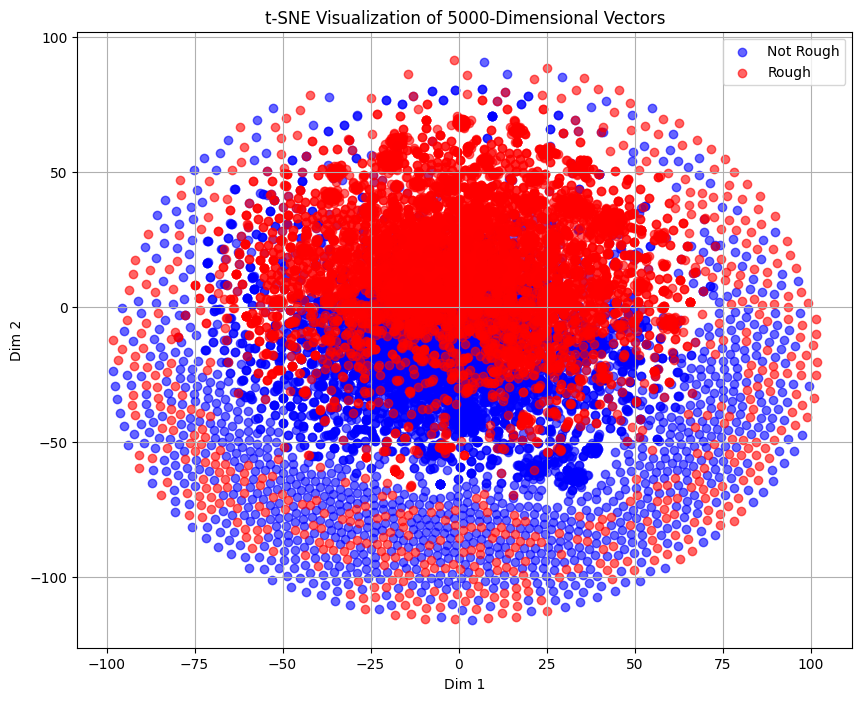

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(tsne_df[tsne_df['is_rough'] == 0]['Dim1'], tsne_df[tsne_df['is_rough'] == 0]['Dim2'],
            color='blue', label='Not Rough', alpha=0.6)
plt.scatter(tsne_df[tsne_df['is_rough'] == 1]['Dim1'], tsne_df[tsne_df['is_rough'] == 1]['Dim2'],
            color='red', label='Rough', alpha=0.6)

plt.title('t-SNE Visualization of 5000-Dimensional Vectors')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
sum=[]
for i in range(len(temp_df)):
   sum.append(temp_df.iloc[i].sum())

In [ ]:
tfidf_df['sum']=sum

In [ ]:
tf_idf=tfidf_df.sample(len(temp_df))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: ylabel='sum'>

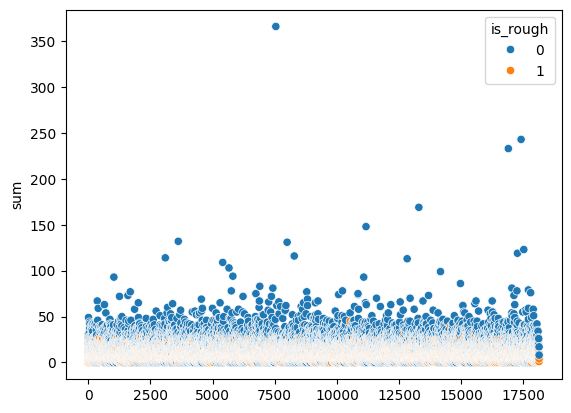

In [ ]:
sns.scatterplot(x=range(len(df1)),y=tfidf_df['sum'],hue=tfidf_df['is_rough'],data=tfidf_df)

<Axes: xlabel='sum', ylabel='Density'>

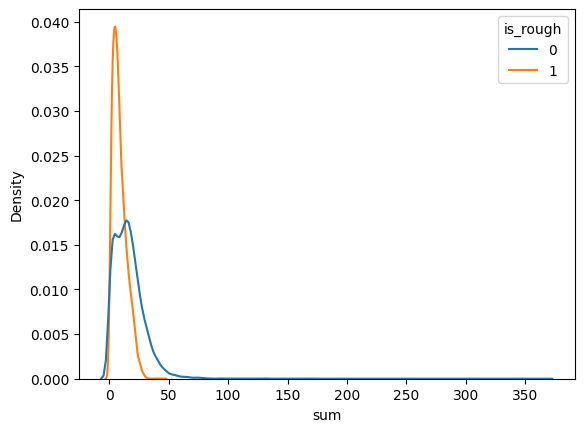

In [ ]:
sns.kdeplot(x=tfidf_df['sum'],hue=tfidf_df['is_rough'],data=tfidf_df)

,0,1,2,3,4,5,6,7,8,9,...,5992,5993,5994,5995,5996,5997,5998,5999,is_rough,sum
14773,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,25
14235,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,20
16512,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,34
2653,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,22
2452,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,29
9761,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
5606,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,19
6373,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,21


In [ ]:
!pip install cloudpickle

In [ ]:
X=temp_df.iloc[:,:-1]
y=temp_df['is_rough']

In [ ]:
X

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
9606,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3702,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11544,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2278,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11629,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2972,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8112,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()

# Fit the model
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[948, 843],
       [954, 882]])

In [ ]:
import nltk
from nltk.corpus import stopwords

In [ ]:
stop=stopwords.words('nepali')

In [ ]:
def remove_sropwords(text):
    tokens=text.split()
    cleaned_text=[word for word in tokens if word not in stop]
    return " ".join(cleaned_text)

In [ ]:
def query_creator(text):
    text=remove_stopwords(text)
    print(text)
    q_bow=cv.transform([text]).toarray()
    return q_bow

In [ ]:
q_bow=query_creator("धेरै माया गर्दा रैछन")
rf.predict(q_bow)

माया गर्दा रैछन


array([1])

In [ ]:
q_bow[0].shape

(4000,)

In [ ]:
rf.predict(q_bow)

array([0])

#SVM


In [ ]:
from sklearn import svm

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
clf = svm.SVC(kernel='linear')
clf.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
  y_pred = clf.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.9279141104294478

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1390,   90],
       [ 145, 1635]])

In [ ]:
q_bow=query_creator("")
clf.predict(q_bow)

कामी


array([1])

In [ ]:
import pickle
with open('rough_classifier_svm.pkl','wb') as file:
  pickle.dump(clf,file)

In [ ]:
with open('count_vectorizer.pkl', 'wb') as file:
    pickle.dump(cv, file)

In [ ]:
with open('/content/count_vectorizer.pkl', 'rb') as file:
    loaded_cv = pickle.load(file)

In [ ]:
X_new_vec = loaded_cv.transform(["New text data for transformation"])
X_new_vec.toarray().shape

(1, 5000)

In [ ]:
!pip install -U scikit-learn==1.3.2


In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred = xgb.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.8505652054039151

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1569,  222],
       [ 320, 1516]])

In [ ]:
q_bow=query_creator("हाम्रो देश सानो छ")
xgb.predict(q_bow)

हाम्रो देश सानो


array([1])

#naive bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
gnb = MultinomialNB(alpha=10)
gnb.fit(X_train, y_train)

MultinomialNB(alpha=10)

In [ ]:
y_pred=gnb.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.8552522746071133

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1413,  378],
       [ 155, 1681]])

In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
param_grid = {'alpha': [0.01, 0.1, 0.5, 1.0, 10]}
grid_search = GridSearchCV(gnb, param_grid, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(alpha=0.1),
             param_grid={'alpha': [0.01, 0.1, 0.5, 1.0, 10]})

In [ ]:
best_model = grid_search.best_estimator_
print("Best alpha:", grid_search.best_params_)

Best alpha: {'alpha': 10}


In [ ]:
q_bow=query_creator('हाम्रो देश सानो छ')
gnb.predict(q_bow)

हाम्रो देश सानो


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(


array([1])

array([1])

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel='rbf')
model.fit(X_train, y_train)

SVC()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.8489109456851393

In [ ]:
confusion_matrix(y_test,y_pred)

array([[1424,  381],
       [ 167, 1655]])

In [ ]:
q_bow=query_creator('धारामा पानी सफा छैन')
model.predict(q_bow)

धारामा पानी सफा


array([1])

SyntaxError: invalid syntax (<ipython-input-2-5cae01a5ea0b>, line 1)